<a href="https://colab.research.google.com/github/JustinStutler/sarkar-computer-vision-lectures/blob/main/4_2_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4.2 HW
Justin Stutler

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

print(cv2.__version__)
np.set_printoptions(precision=2, suppress=True)

5.0.0


# Load Images

In [2]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/4.2 Photos/'
!ls "$data_dir"

Mounted at /content/drive
10.jpg	12.jpg	14.jpg	16.jpg	2.jpg  4.jpg  6.jpg  8.jpg
11.jpg	13.jpg	15.jpg	1.jpg	3.jpg  5.jpg  7.jpg  9.jpg


## Display Original Images

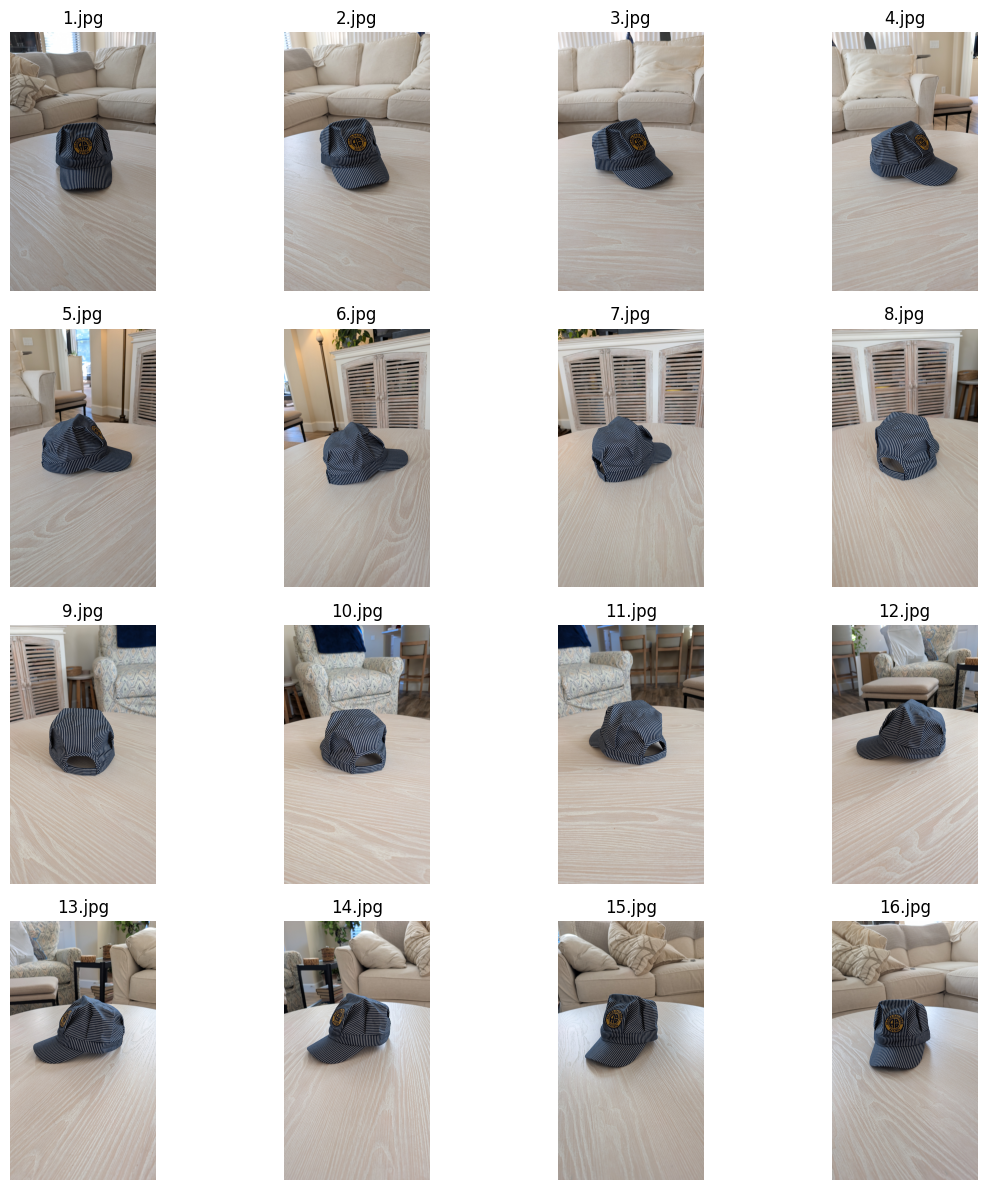

In [4]:
fig, ax = plt.subplots(4, 4, figsize=(12, 12))

i = 1
while i < 17:
  img = cv2.imread(data_dir + str(i) +'.jpg')
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  r = (i-1) // 4
  c = (i-1) % 4

  ax[r, c].imshow(img)
  ax[r, c].set_title(str(i) + '.jpg')
  ax[r, c].axis('off')
  i = i + 1

plt.tight_layout()
plt.show()

## Display Grayscale Images

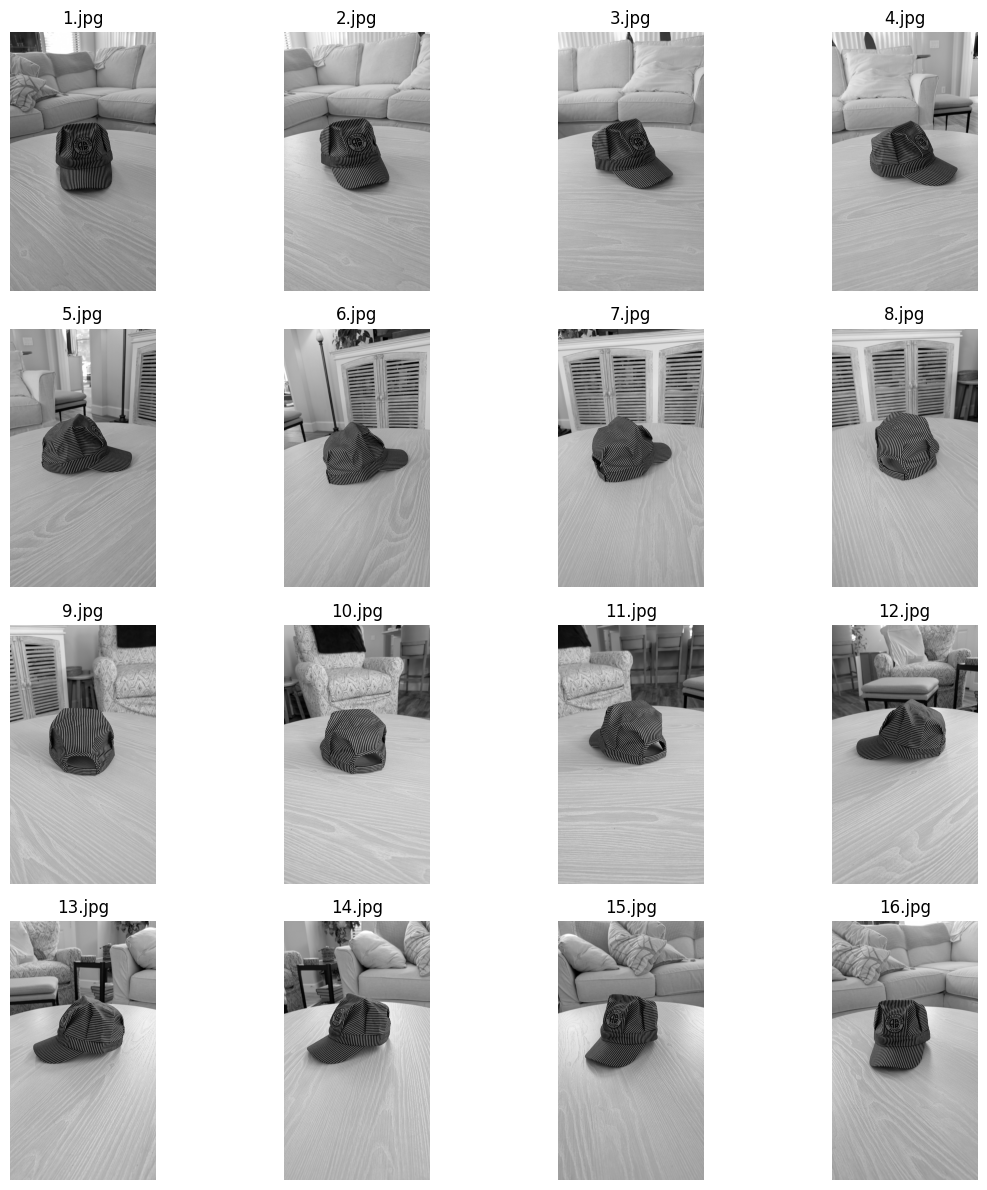

In [6]:
fig, ax = plt.subplots(4, 4, figsize=(12, 12))

i = 1
images = []
while i < 17:
  img = cv2.imread(data_dir + str(i) +'.jpg')
  img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  images.append(img) # store grayscale images in list to use for SIFT

  r = (i-1) // 4
  c = (i-1) % 4

  ax[r, c].imshow(img, cmap = 'gray')
  ax[r, c].set_title(str(i) + '.jpg')
  ax[r, c].axis('off')
  i = i + 1

plt.tight_layout()
plt.show()

# Core

## Find and Match SIFT Features

In [ ]:
image_1 = images[0]
image_2 = images[1]

print("Input image size:", image_1.shape)

sift = cv2.SIFT_create()
# For more details see https://docs.opencv.org/master/d7/d60/classcv_1_1SIFT.html
# Default values
# static Ptr<SIFT> cv::SIFT::create	(	int 	nfeatures = 0,
# int 	nOctaveLayers = 3,
# double 	contrastThreshold = 0.04,
# double 	edgeThreshold = 10,
# double 	sigma = 1.6
# )
#
# nfeatures: The number of best features to retain. The features are ranked by their scores
#           (measured in SIFT algorithm as the local contrast)
# nOctaveLayers: The number of layers in each octave. 3 is the value used in D. Lowe paper.
#           The number of octaves is dependent on the image resolution.
# contrastThreshold: The contrast threshold used to filter out weak features in semi-uniform
#           (low-contrast) regions. The larger the threshold, the less features are produced by
#           the detector.
# edgeThreshold: The threshold used to filter out edge-like features. Note that the its meaning
#           is different from the contrastThreshold, i.e. the larger the edgeThreshold, the less
#           features are filtered out (more features are retained).
# sigma: The sigma of the Gaussian applied to the input image at the octave #0. If your image is
#           captured with a weak camera with soft lenses, you might want to reduce the number.

keypoints_1, descriptors_1 = sift.detectAndCompute(image_1, None)
keypoints_2, descriptors_2 = sift.detectAndCompute(image_2, None)

# Keypoint class is described in at https://docs.opencv.org/master/d2/d29/classcv_1_1KeyPoint.html
# It is a data structure for salient point detectors in OpenCV. The class instance stores a keypoint,
# i.e. a point feature.
# The keypoint is characterized by the 2D position, scale (proportional to the diameter of the
# neighborhood that needs to be taken into account), orientation and some other parameters.
# The keypoint neighborhood is then analyzed by another algorithm that builds a descriptor
# (usually represented as a feature vector). The keypoints representing the same object in
# different images can then be matched using KDTree or another method.
def unpackSIFTOctave(keypoint):
    """unpackSIFTOctave(kpt)->(octave,layer,scale)
    @created by Silencer at 2018.01.23 11:12:30 CST
    @brief Unpack Sift Keypoint by Silencer
    @param kpt: cv2.KeyPoint (of SIFT)
    """
    _octave = keypoint.octave
    octave = _octave&0xFF
    layer  = (_octave>>8)&0xFF
    if octave>=128:
        octave |= -128
    if octave>=0:
        scale = float(1/(1<<octave))
    else:
        scale = float(1<<-octave)
    return (octave, layer, scale)

#for i in range(len(keypoints_1)) :
i = 5
octave, layer, scale = unpackSIFTOctave(keypoints_1[i])
print('\n Keypoint #{} (of {}) in (image 1):\n angle={:0.2f}, (octave, layer, scale)={:0.2f} {:0.2f} {:0.2f}, size={:0.2f}, pt={}\n'.format(i, len(keypoints_1), keypoints_1[i].angle,
                                                                    octave, layer, scale,
                                                                    keypoints_1[i].size,
                                                                    keypoints_1[i].pt))
print('Note: 2^octave * scale = 1. So, octave = -1 => scale = 2')
print('\n Keypoint {} descriptor (image 1): Shape{}, Values[5]=\n{}'.format(i, descriptors_1.shape, descriptors_1[i,:]))

# FEATURE MATCHING
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)
# This is Brute Force OpenCV matcher: https://docs.opencv.org/master/d3/da1/classcv_1_1BFMatcher.html
# For each descriptor in the first set, this matcher finds the closest descriptor in the second set
# by trying each one. This descriptor matcher supports masking permissible matches of descriptor sets.
# crossCheck -- If it is false, this is will be default BFMatcher behaviour when it finds the
#               k nearest neighbors for each query descriptor. If crossCheck==TRUE, then the
#               knnMatch() method with k=1 will only return pairs (i,j) such that for i-th query
#               descriptor the j-th descriptor in the matcher's collection is the nearest and vice versa,
#               i.e. the BFMatcher will only RETURN CONSISTENT pairs. Such technique usually produces best
#               results with minimal number of outliers when there are enough matches. This is alternative
#               to the ratio test, used by D. Lowe in SIFT paper.

matches = bf.match(descriptors_1, descriptors_2)
matches = sorted(matches, key = lambda x:x.distance)

# The match class is described here: https://docs.opencv.org/master/d4/de0/classcv_1_1DMatch.html
print('\n Matches: # = {}, 7th entry: distance = {} between features {} (of {}) and {} \n'.format(len(matches),
                                                                                      matches[7].distance,
                                                                                      matches[7].trainIdx,
                                                                                      matches[7].imgIdx,
                                                                                      matches[7].queryIdx))

#----------------------------------Display-------------------------------------------------------
# draw the detected key points for display purposes
sift_image1 = cv2.drawKeypoints(image_1, keypoints_1, image_1, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
sift_image2 = cv2.drawKeypoints(image_2, keypoints_2, image_2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
# draw matches
match_image = cv2.drawMatches(image_1, keypoints_1, image_2, keypoints_2, matches[:20], image_2, flags=2)


fig, ax = plt.subplots(nrows=4, ncols=2)
fig.set_size_inches (15, 20)

ax[0,0].imshow(image_1, 'gray')
ax[0,1].imshow(image_2, 'gray')
ax[1,0].imshow(sift_image1)
ax[1,0].set_title('SIFT features')
ax[1,1].imshow(sift_image2)
ax[1,1].set_title('SIFT features')
ax[2,0].imshow(descriptors_1.transpose())
ax[2,0].set_title('SIFT descriptors')
ax[2,0].set_xlabel('SIFT points')
ax[2,0].set_ylabel('128 dim descriptor')
ax[2,1].imshow(descriptors_2.transpose())
ax[2,1].set_title('SIFT descriptors')
ax[2,1].set_xlabel('SIFT points')
ax[2,1].set_ylabel('128 dim descriptor')
ax[3,0].imshow(match_image)

plt.tight_layout()
plt.show()


Input image size: (4032, 2268)

 Keypoint #5 (of 23982) in (image 1):
 angle=129.03, (octave, layer, scale)=-1.00 1.00 2.00, size=2.08, pt=(5.337027549743652, 2668.02490234375)

Note: 2^octave * scale = 1. So, octave = -1 => scale = 2

 Keypoint 5 descriptor (image 1): Shape(23982, 128), Values[5]=
[  0.   0.   0.  21. 101.  56.   5.   0.  21.   1.   0.   1.  24.  65.
  38.  24. 116.   2.   0.   0.  28.  20.  12.  86.   6.   0.   0.   1.
 152.  61.   4.   7.   1.   4.   3.  49.  55.   9.  14.   6.  42.  12.
   4.  30.  44.  41.  20.  11. 152.  16.   1.   6.  50.  29.  12.  77.
  12.   0.   0.   9. 152.  58.   6.  12.   8.  24.   7.  13.  18.  15.
  46.  23.  42.   6.   2.   7.  99.  70.  17.   6. 152.  70.  14.  42.
  69.  11.   3.  15.  15.  10.   7. 100. 152.   6.   1.   3.  34. 107.
  28.  13.   5.   2.   2.  11.  11.  12.   8.  20.  74.  18.   2.   3.
  67.  47.   7.  13.  25.   6.   2.   4.   2.   5.   4.  18.  36.   0.
   0.   0.]
